<a href="https://colab.research.google.com/github/Kamruzzaman2200/Ai/blob/main/22234103167.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Install & Import Libraries

In [28]:
import subprocess
import sys

try:
    print("Installing required packages: ucimlrepo, xgboost, lightgbm...")
    subprocess.run([sys.executable, "-m", "pip", "install", "ucimlrepo", "xgboost", "lightgbm"], check=True)
    print("Successfully installed packages.")
except subprocess.CalledProcessError as e:
    print(f"Failed to install packages: {e}")
    pass
except FileNotFoundError:
    print("pip command not found. Please ensure pip is installed and in your PATH.")
    pass


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from io import StringIO
# Data Fetching
try:
    from ucimlrepo import fetch_ucirepo
    print("Successfully imported 'ucimlrepo'")
except ImportError:
    print("Failed to import 'ucimlrepo'.")

    print("Attempting to read from user-provided file 'default of credit card clients.xls - Data.csv'")
    try:

        df_from_file = pd.read_csv('default of credit card clients.xls - Data.csv', header=1)

        # Drop the ID column
        if 'ID' in df_from_file.columns:
            df_from_file = df_from_file.drop('ID', axis=1)

        # Rename the target column
        df_from_file = df_from_file.rename(columns={'default payment next month': 'DEFAULT'})

        # Manually create X and y
        y = df_from_file['DEFAULT']
        X = df_from_file.drop('DEFAULT', axis=1)

        # Rename X columns to match the script's expectations
        X.columns = [
            'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE',
            'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
            'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
            'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
        ]
        print("Successfully loaded and parsed data from user-provided CSV.")

    except FileNotFoundError:
        print("CSV file 'default of credit card clients.xls - Data.csv' not found. Aborting.")
        sys.exit(1) # Exit the script
    except Exception as e:
        print(f"An error occurred while reading the CSV: {e}. Aborting.")
        sys.exit(1)

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
# Models
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
try:
    from xgboost import XGBClassifier
    print("Successfully imported 'XGBClassifier'")
except ImportError:
    print("Failed to import 'XGBClassifier' even after attempting install.")
    XGBClassifier = None # Set to None so script can check
try:
    from lightgbm import LGBMClassifier
    print("Successfully imported 'LGBMClassifier'")
except ImportError:
    print("Failed to import 'LGBMClassifier' even after attempting install.")
    LGBMClassifier = None # Set to None

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
# Settings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("All libraries imported.")

Installing required packages: ucimlrepo, xgboost, lightgbm...
Successfully imported 'ucimlrepo'
Successfully imported 'XGBClassifier'
Successfully imported 'LGBMClassifier'
All libraries imported.


#Fetch UCI Dataset

In [29]:
# === Cell 2: Fetch UCI Dataset ===
# This part will be skipped if we loaded from file in Cell 1
if 'X' not in locals() or 'y' not in locals():
    print("\nFetching Default of Credit Card Clients dataset (id=350) from UCI...")
    try:
        default_of_credit_card_clients = fetch_ucirepo(id=350)
        # data (as pandas dataframes)
        X_uci = default_of_credit_card_clients.data.features
        y_uci = default_of_credit_card_clients.data.targets

        #  Data Preparation & Column Renaming ===
        column_names = [
            'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE',
            'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
            'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
            'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
        ]
        X = X_uci.copy()
        X.columns = column_names
        y = y_uci.iloc[:, 0].copy()
        y.name = 'DEFAULT'
        print("Dataset fetched successfully from UCI and columns renamed.")

        #  Initial Data Inspection (Metadata) ===
        print("\n--- Dataset Metadata ---")
        # print(default_of_credit_card_clients.metadata) # Commented out to reduce noise
        print("\n--- Variable Information ---")
        # print(default_of_credit_card_clients.variables) # Commented out to reduce noise

    except Exception as e:
        print(f"Failed to fetch from UCI: {e}. Aborting.")
        sys.exit(1)
else:
    print("\nSkipping UCI fetch and renaming (loaded from file).")

print("\n--- Features (X) Head ---")
print(X.head())
print("\n--- Features (X) Info ---")
X.info()


Skipping UCI fetch and renaming (loaded from file).

--- Features (X) Head ---
   LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0      20000    2          2         1   24      2      2     -1     -1   
1     120000    2          2         2   26     -1      2      0      0   
2      90000    2          2         2   34      0      0      0      0   
3      50000    2          2         1   37      0      0      0      0   
4      50000    1          2         1   57     -1      0     -1      0   

   PAY_5  ...  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  \
0     -2  ...        689          0          0          0         0       689   
1      0  ...       2682       3272       3455       3261         0      1000   
2      0  ...      13559      14331      14948      15549      1518      1500   
3      0  ...      49291      28314      28959      29547      2000      2019   
4      0  ...      35835      20940      19146      19131      2

In [8]:
print(f"Shape of features (X_uci): {X_uci.shape}")
print(f"Shape of target (y_uci): {y_uci.shape}")

Shape of features (X_uci): (30000, 23)
Shape of target (y_uci): (30000, 1)


#Combine for EDA & Final Checks

In [31]:

df = pd.concat([X, y], axis=1)
print("\n--- Checking for Missing Values ---")
print(df.isnull().sum().sort_values(ascending=False))
# Handle potential NaNs just in case, though this dataset is clean
df = df.dropna()
print(f"Data shape after dropping potential NaNs: {df.shape}")


--- Checking for Missing Values ---
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
DEFAULT      0
dtype: int64
Data shape after dropping potential NaNs: (30000, 24)


#Define Target and Features

In [32]:
target_col = 'DEFAULT'
y = df[target_col].astype(int) # Ensure target is integer
X = df.drop(target_col, axis=1)

print(f"\nOriginal Features shape: {X.shape}")
print(f"Target shape: {y.shape}")


Original Features shape: (30000, 23)
Target shape: (30000,)


#EDA - Target Variable Distribution


Saved 'target_distribution.png'


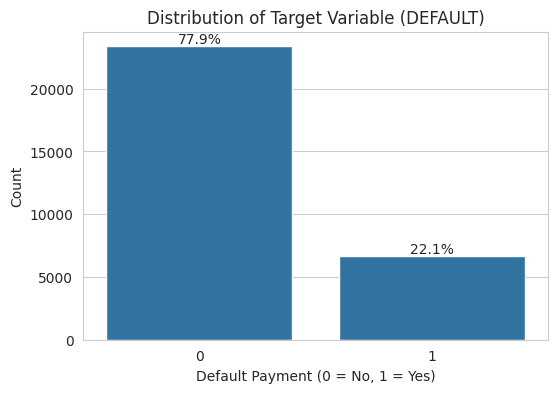

In [33]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=y)
plt.title('Distribution of Target Variable (DEFAULT)')
plt.xlabel('Default Payment (0 = No, 1 = Yes)')
plt.ylabel('Count')
total = len(y)
if total > 0:
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        x_ax = p.get_x() + p.get_width() / 2
        y_ax = p.get_height()
        ax.annotate(percentage, (x_ax, y_ax), ha='center', va='bottom')
plt.savefig('target_distribution.png', bbox_inches='tight')
print("\nSaved 'target_distribution.png'")

#EDA - Categorical Features vs. Default

Saved 'categorical_features_vs_default.png'


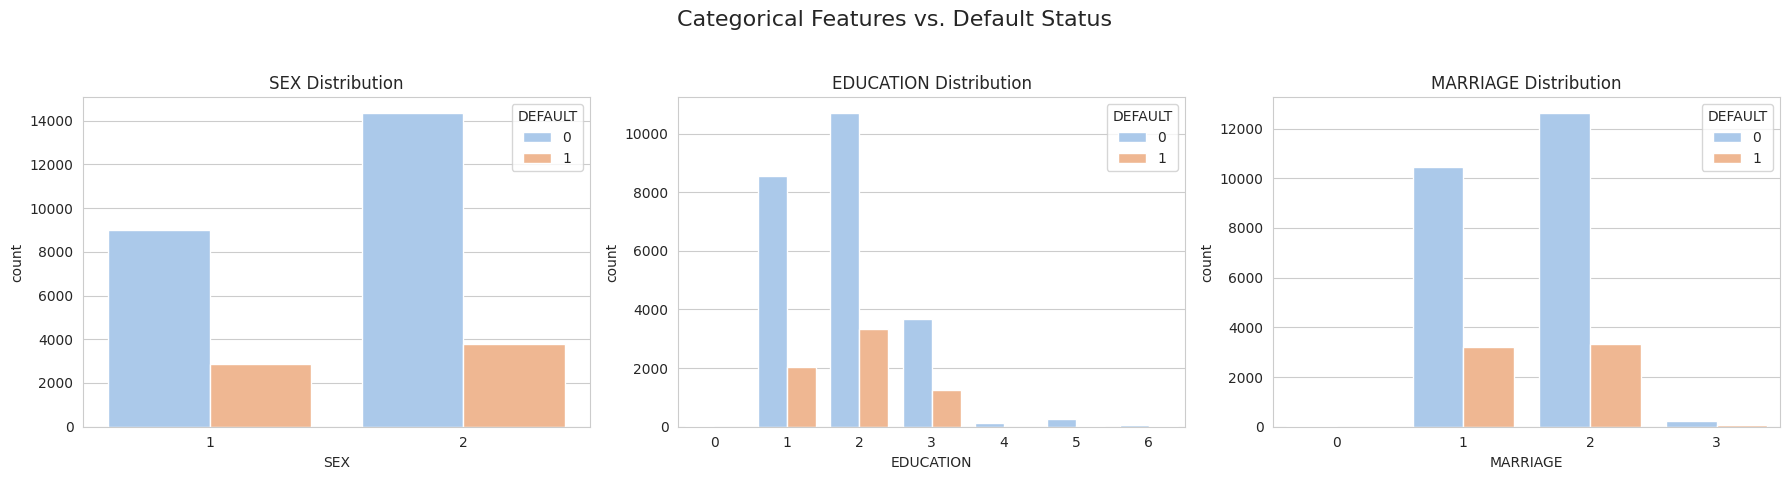

In [34]:
cat_features = ['SEX', 'EDUCATION', 'MARRIAGE']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Categorical Features vs. Default Status', fontsize=16)
for i, col in enumerate(cat_features):
    sns.countplot(ax=axes[i], x=col, hue=y, data=df, palette='pastel')
    axes[i].set_title(f'{col} Distribution')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('categorical_features_vs_default.png')
print("Saved 'categorical_features_vs_default.png'")

#EDA - Numerical Features (Limit & Age)

Saved 'numerical_features_vs_default.png'


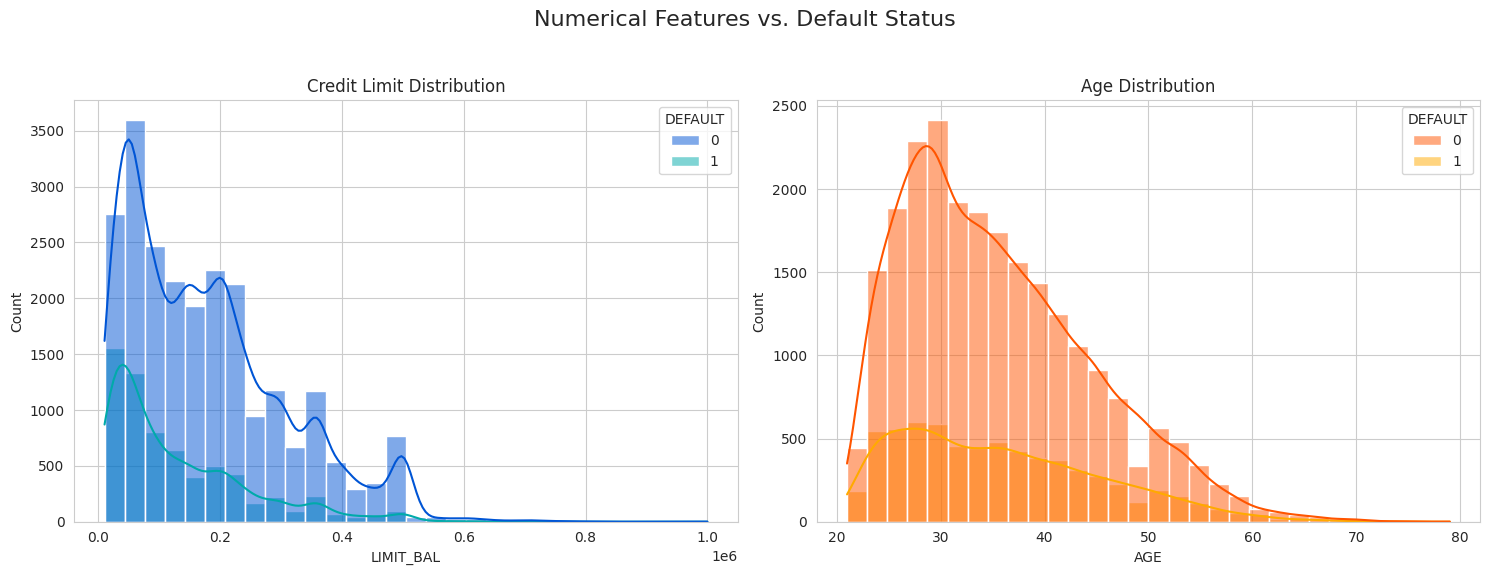

In [35]:
# === Cell 9: EDA - Numerical Features (Limit & Age) ===
num_features = ['LIMIT_BAL', 'AGE']
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Numerical Features vs. Default Status', fontsize=16)
sns.histplot(ax=axes[0], data=df, x='LIMIT_BAL', hue=target_col, kde=True, bins=30, palette='winter')
axes[0].set_title('Credit Limit Distribution')
sns.histplot(ax=axes[1], data=df, x='AGE', hue=target_col, kde=True, bins=30, palette='autumn')
axes[1].set_title('Age Distribution')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('numerical_features_vs_default.png')
print("Saved 'numerical_features_vs_default.png'")

#EDA - Correlation Heatmap

Saved 'correlation_matrix.png'


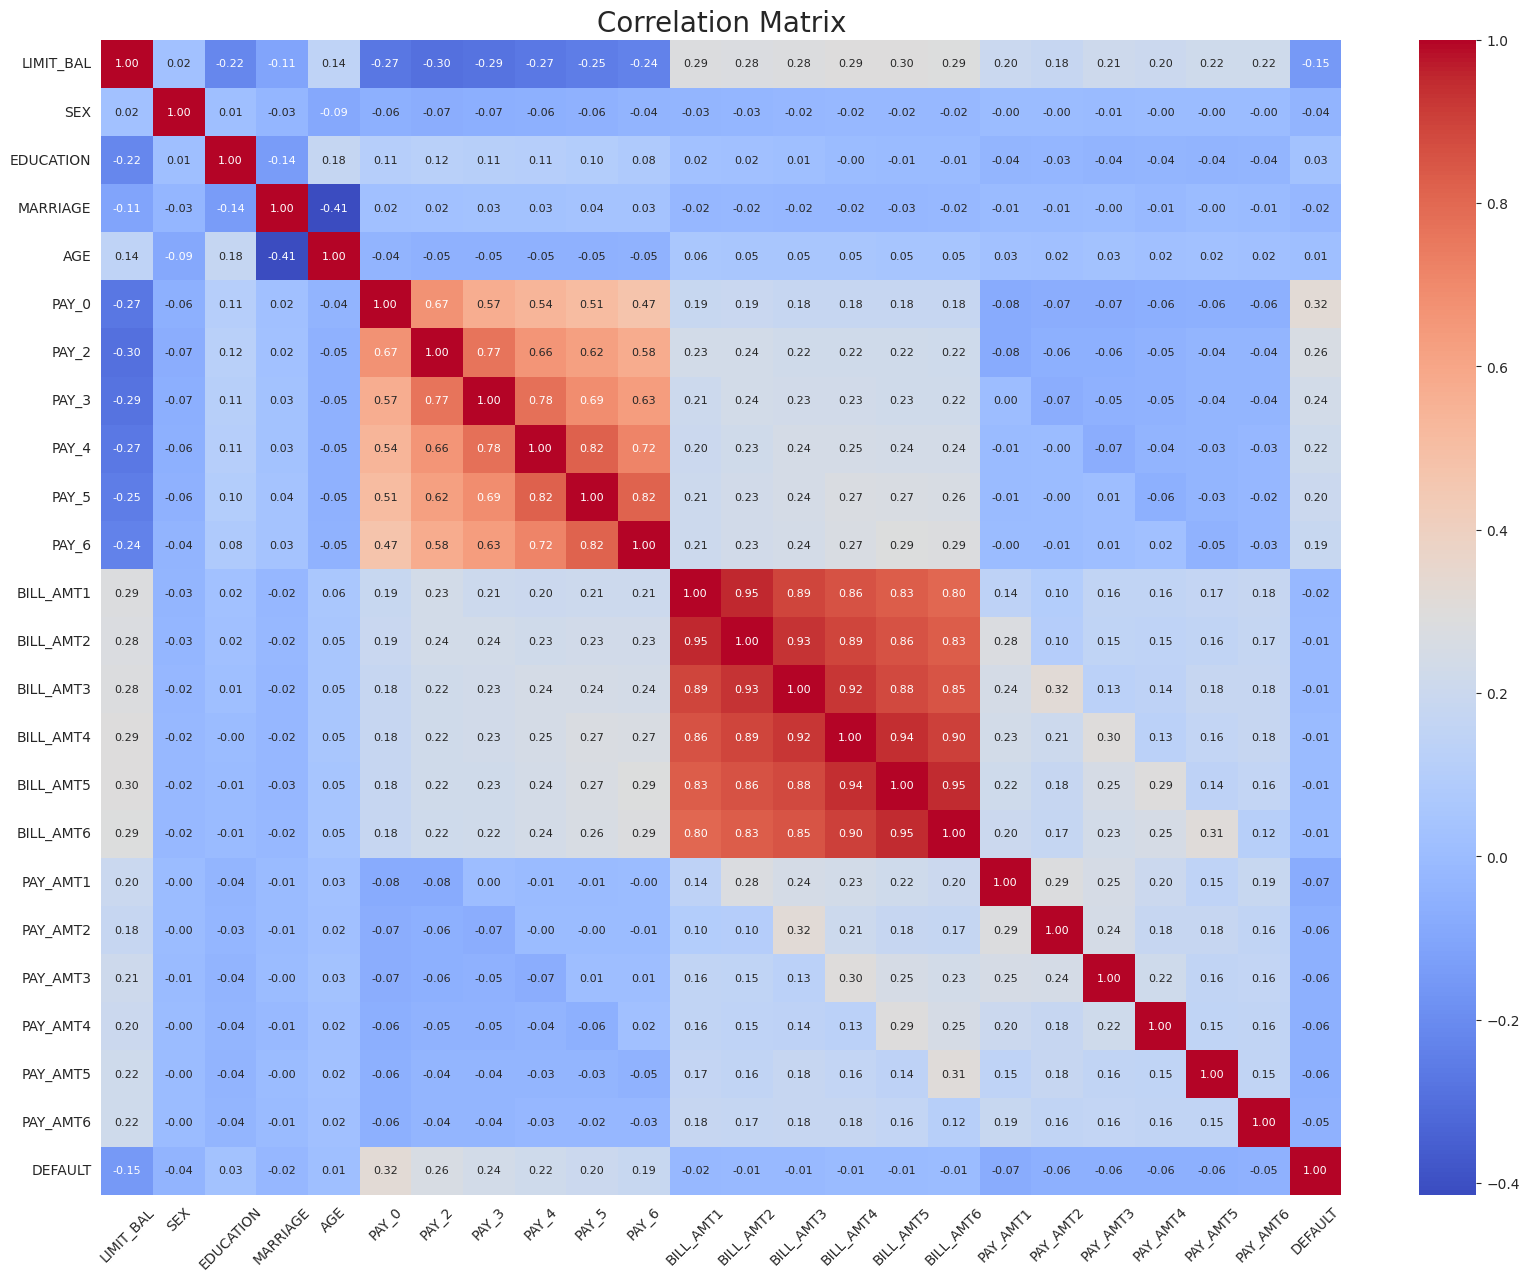

In [36]:
plt.figure(figsize=(20, 15))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', annot_kws={"size": 8})
plt.title('Correlation Matrix', fontsize=20)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.savefig('correlation_matrix.png', bbox_inches='tight')
print("Saved 'correlation_matrix.png'")

#Feature Engineering

In [37]:

print("\n--- Starting Feature Engineering ---")
# Keep track of original number of features
num_orig_features = len(X.columns)

# Start with the clean X
X_fe = X.copy()

# 1. Payment Status Features
pay_cols = [f'PAY_{i}' for i in [0, 2, 3, 4, 5, 6]]
X_fe['PAY_AVG'] = X_fe[pay_cols].mean(axis=1)
X_fe['PAY_LATE_COUNT'] = (X_fe[pay_cols] > 0).sum(axis=1)

# 2. Bill and Utilization Features
bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]
X_fe['BILL_AVG'] = X_fe[bill_cols].mean(axis=1)
# Add 1e-6 to avoid division by zero, just in case
X_fe['CREDIT_UTIL_AVG'] = X_fe['BILL_AVG'] / (X_fe['LIMIT_BAL'] + 1e-6)
X_fe['CREDIT_UTIL_1'] = X_fe['BILL_AMT1'] / (X_fe['LIMIT_BAL'] + 1e-6)

# 3. Payment Amount and Ratio Features
pay_amt_cols = [f'PAY_AMT{i}' for i in range(1, 7)]
X_fe['PAY_AMT_AVG'] = X_fe[pay_amt_cols].mean(axis=1)
# Ratio of average payment to average bill
X_fe['PAY_TO_BILL_AVG'] = X_fe['PAY_AMT_AVG'] / (X_fe['BILL_AVG'] + 1e-6)

# 4. Demographic-Limit Interaction
X_fe['LIMIT_PER_AGE'] = X_fe['LIMIT_BAL'] / (X_fe['AGE'] + 1e-6)

# Clean up any potential inf values if division by zero occurred
X_fe.replace([np.inf, -np.inf], 0, inplace=True)
# Fill any potential NaNs created with 0 as well
X_fe.fillna(0, inplace=True)

# Overwrite X with our new feature-engineered dataframe
X = X_fe

print(f"Created {len(X.columns) - num_orig_features} new features.")
print(f"New shape of X: {X.shape}")
print("\n--- New Features Head ---")
print(X[['PAY_AVG', 'PAY_LATE_COUNT', 'BILL_AVG', 'CREDIT_UTIL_AVG', 'PAY_TO_BILL_AVG', 'LIMIT_PER_AGE']].head())


--- Starting Feature Engineering ---
Created 8 new features.
New shape of X: (30000, 31)

--- New Features Head ---
    PAY_AVG  PAY_LATE_COUNT      BILL_AVG  CREDIT_UTIL_AVG  PAY_TO_BILL_AVG  \
0 -0.333333               2   1284.000000         0.064200         0.089434   
1  0.500000               2   2846.166667         0.023718         0.292791   
2  0.000000               0  16942.166667         0.188246         0.108388   
3  0.000000               0  38555.666667         0.771113         0.036259   
4 -0.333333               0  18223.166667         0.364463         0.540054   

   LIMIT_PER_AGE  
0     833.333299  
1    4615.384438  
2    2647.058746  
3    1351.351315  
4     877.192967  


#Train-Test Split

In [38]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts(normalize=True)}")
print(f"y_test distribution:\n{y_test.value_counts(normalize=True)}")


X_train shape: (24000, 31)
X_test shape: (6000, 31)
y_train distribution:
DEFAULT
0    0.778792
1    0.221208
Name: proportion, dtype: float64
y_test distribution:
DEFAULT
0    0.778833
1    0.221167
Name: proportion, dtype: float64


#Define Preprocessing Steps

In [39]:

# Identify original numerical features
numeric_features = ['LIMIT_BAL', 'AGE'] + \
                   [f'BILL_AMT{i}' for i in range(1, 7)] + \
                   [f'PAY_AMT{i}' for i in range(1, 7)]
# Add our new engineered features
new_numeric_features = [
    'PAY_AVG', 'PAY_LATE_COUNT', 'BILL_AVG', 'CREDIT_UTIL_AVG',
    'CREDIT_UTIL_1', 'PAY_AMT_AVG', 'PAY_TO_BILL_AVG', 'LIMIT_PER_AGE'
]
numeric_features.extend(new_numeric_features)
# Identify categorical features
categorical_features = ['SEX', 'EDUCATION', 'MARRIAGE'] + \
                       [f'PAY_{i}' for i in [0, 2, 3, 4, 5, 6]]

# Ensure all features exist in X_train (in case of error)
numeric_features = [f for f in numeric_features if f in X_train.columns]
categorical_features = [f for f in categorical_features if f in X_train.columns]


print(f"\nFound {len(numeric_features)} total numerical features.")
print(f"Found {len(categorical_features)} categorical features.")

# Create transformers
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Create the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

print("Preprocessor (ColumnTransformer) updated successfully.")


Found 22 total numerical features.
Found 9 categorical features.
Preprocessor (ColumnTransformer) updated successfully.


#Handle Class Imbalance

In [40]:

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nCalculated 'scale_pos_weight' for imbalance: {scale_pos_weight:.2f}")


Calculated 'scale_pos_weight' for imbalance: 3.52


#Initialize Models

In [41]:

print("\nInitializing models with parameters to reduce overfitting...")

models = {
    'LR (L1/Lasso)': LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000,
                                       penalty='l1', solver='liblinear', n_jobs=-1), # L1 Regularization
    'Ridge Classifier': RidgeClassifier(random_state=42, class_weight='balanced'), # L2 Regularization
    'DT (Depth=5)': DecisionTreeClassifier(random_state=42, class_weight='balanced',
                                         max_depth=5), # Limit depth
    'RF (Depth=10)': RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1,
                                         max_depth=10), # Limit depth
    'Linear SVC': LinearSVC(random_state=42, class_weight='balanced', max_iter=5000, dual=False), # Already regularized
    'K-Neighbors': KNeighborsClassifier(n_jobs=-1),
    'Gaussian NB': GaussianNB(),
    'AdaBoost': AdaBoostClassifier(random_state=42), # Often robust to overfitting
    'GBT (Depth=3)': GradientBoostingClassifier(random_state=42, max_depth=3), # Limit depth
    'LDA': LinearDiscriminantAnalysis()
}

# Add XGB and LGBM only if they were successfully imported
if XGBClassifier is not None:
    models['XGB (Depth=5)'] = XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight,
                                          eval_metric='logloss', n_jobs=-1,
                                          max_depth=5, reg_alpha=0.1) # Limit depth + L1 reg
else:
    print("Skipping XGBClassifier (import failed).")

if LGBMClassifier is not None:
    models['LGBM (Depth=5)'] = LGBMClassifier(random_state=42, class_weight='balanced', n_jobs=-1, verbosity=-1,
                                           max_depth=5, reg_alpha=0.1) # Limit depth + L1 reg
else:
    print("Skipping LGBMClassifier (import failed).")


print(f"Initialized {len(models)} models for comparison.")


Initializing models with parameters to reduce overfitting...
Initialized 12 models for comparison.


#Create Model Training and Evaluation Loop

In [42]:

results_list = []
for name, model in models.items():
    print(f"--- Training {name} ---")

    # Create the full pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Train the model
    pipeline.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = pipeline.predict(X_test)

    # Get prediction probabilities for ROC AUC
    y_pred_proba_scores = None
    if hasattr(pipeline, 'predict_proba'):
        y_pred_proba_scores = pipeline.predict_proba(X_test)[:, 1]
    elif hasattr(pipeline, 'decision_function'):
        y_pred_proba_scores = pipeline.decision_function(X_test)
    else:
        # Fallback for models without proba or decision_function
        y_pred_proba_scores = None

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    if y_pred_proba_scores is not None:
        roc_auc = roc_auc_score(y_test, y_pred_proba_scores)
    else:
        print(f"Could not compute ROC AUC for {name}, setting to 0.0.")
        roc_auc = 0.0 # Cannot compute ROC-AUC

    # Append results
    results_list.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC AUC': roc_auc
    })

print("\n--- All models trained and evaluated. ---")

--- Training LR (L1/Lasso) ---
--- Training Ridge Classifier ---
--- Training DT (Depth=5) ---
--- Training RF (Depth=10) ---
--- Training Linear SVC ---
--- Training K-Neighbors ---
--- Training Gaussian NB ---
--- Training AdaBoost ---
--- Training GBT (Depth=3) ---
--- Training LDA ---
--- Training XGB (Depth=5) ---
--- Training LGBM (Depth=5) ---

--- All models trained and evaluated. ---


#Compare Model Results

In [43]:
results_df = pd.DataFrame(results_list)
# Sort by F1-Score in descending order
results_df_sorted = results_df.sort_values(by='F1-Score', ascending=False)

print("\n--- Model Comparison Results (Sorted by F1-Score) ---")
print(results_df_sorted.to_markdown(index=False, floatfmt=".4f"))
# Save results to a CSV
results_df_sorted.to_csv('model_comparison_results_v2_FE.csv', index=False)
print("\nSaved 'model_comparison_results_v2_FE.csv'")


--- Model Comparison Results (Sorted by F1-Score) ---
| Model            |   Accuracy |   Precision |   Recall |   F1-Score |   ROC AUC |
|:-----------------|-----------:|------------:|---------:|-----------:|----------:|
| RF (Depth=10)    |     0.7845 |      0.5113 |   0.5787 |     0.5429 |    0.7776 |
| LGBM (Depth=5)   |     0.7548 |      0.4600 |   0.6247 |     0.5299 |    0.7766 |
| DT (Depth=5)     |     0.7417 |      0.4421 |   0.6420 |     0.5237 |    0.7665 |
| LR (L1/Lasso)    |     0.7750 |      0.4923 |   0.5561 |     0.5223 |    0.7607 |
| XGB (Depth=5)    |     0.7522 |      0.4550 |   0.6089 |     0.5208 |    0.7649 |
| Linear SVC       |     0.7773 |      0.4969 |   0.5426 |     0.5187 |    0.7569 |
| Ridge Classifier |     0.7768 |      0.4959 |   0.5411 |     0.5175 |    0.7558 |
| LDA              |     0.8170 |      0.6470 |   0.3798 |     0.4786 |    0.7547 |
| GBT (Depth=3)    |     0.8192 |      0.6681 |   0.3625 |     0.4700 |    0.7795 |
| AdaBoost         | 

#Visualize Model Comparison

Saved 'model_comparison_plot_v2_FE.png'


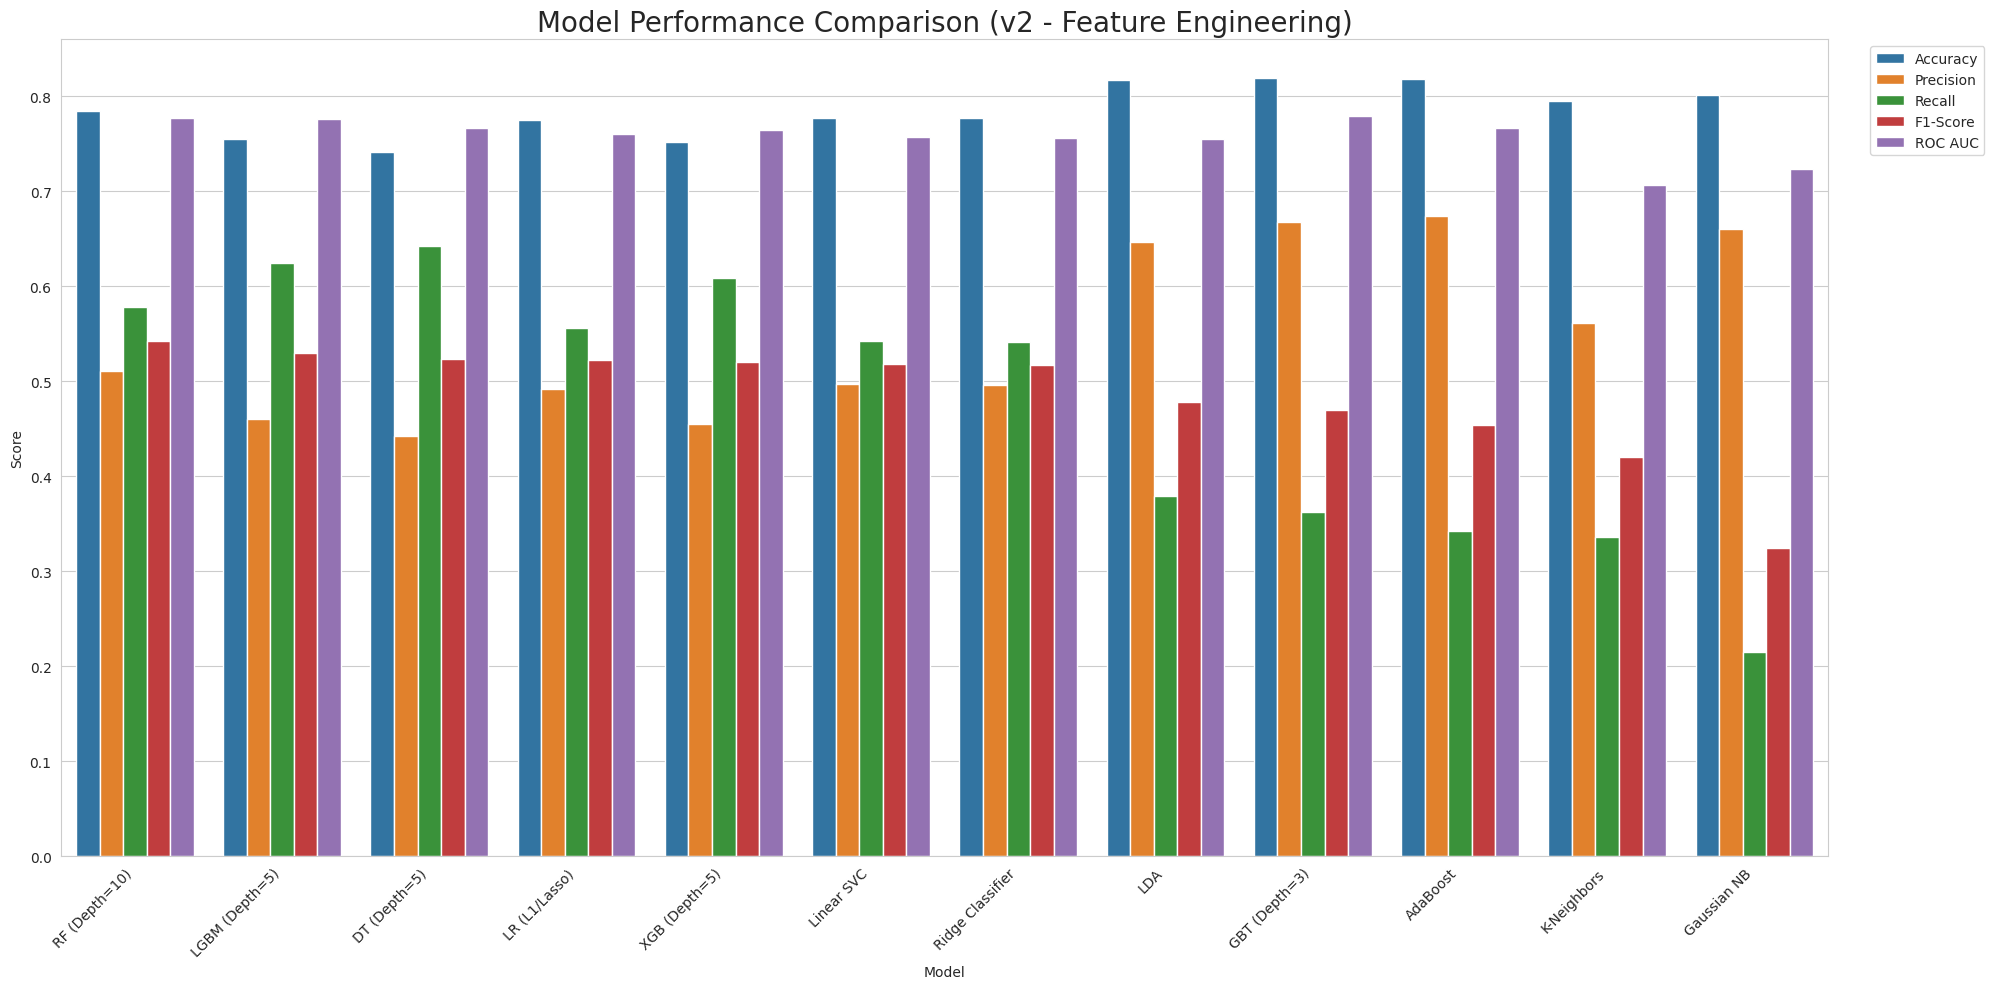

In [45]:

results_melted = results_df_sorted.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(20, 10))
sns.barplot(
    data=results_melted,
    x='Model',
    y='Score',
    hue='Metric'
)
plt.title('Model Performance Comparison (v2 - Feature Engineering)', fontsize=20)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Score')
plt.xlabel('Model')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('model_comparison_plot_v2_FE.png')
print("Saved 'model_comparison_plot_v2_FE.png'")

#In-Depth Analysis of the Best Model

In [46]:

if results_df_sorted.empty:
    print("\nNo models were successfully trained. Skipping best model analysis.")
    # sys.exit() # Commented out to allow notebook to continue
else:
    best_model_name = results_df_sorted.iloc[0]['Model']
    print(f"\n--- In-Depth Analysis of Best Model: {best_model_name} ---")
    # Get the best model from our dictionary
    best_model = models[best_model_name]
    # Re-create and re-fit its pipeline
    best_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', best_model)
    ])
    best_pipeline.fit(X_train, y_train)
    y_pred_best = best_pipeline.predict(X_test)


--- In-Depth Analysis of Best Model: RF (Depth=10) ---


#Best Model - Classification Report

In [47]:

if 'best_model_name' in locals():
    report = classification_report(y_test, y_pred_best)
    print(f"Classification Report for {best_model_name}:\n")
    print(report)
else:
    print("Skipping classification report (no best model found).")

Classification Report for RF (Depth=10):

              precision    recall  f1-score   support

           0       0.88      0.84      0.86      4673
           1       0.51      0.58      0.54      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.80      0.78      0.79      6000



Generating Confusion Matrix...
Saved 'best_model_confusion_matrix_v2_FE.png'


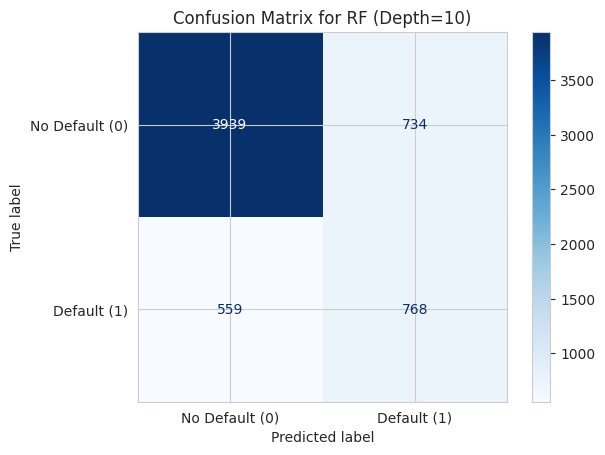

In [48]:
#Best Model - Confusion Matrix ===
if 'best_model_name' in locals():
    print("Generating Confusion Matrix...")
    cm = confusion_matrix(y_test, y_pred_best)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default (0)', 'Default (1)'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Confusion Matrix for {best_model_name}')
    plt.savefig('best_model_confusion_matrix_v2_FE.png')
    print("Saved 'best_model_confusion_matrix_v2_FE.png'")
else:
    print("Skipping confusion matrix (no best model found).")


--- Feature Importance Analysis ---
Remainder is passthrough, but no remainder columns were found.
Model has 'feature_importances_'

Top 10 Most Important Features for RF (Depth=10):
| Feature         |   Importance |
|:----------------|-------------:|
| PAY_AVG         |       0.1243 |
| PAY_LATE_COUNT  |       0.1109 |
| PAY_0_2         |       0.0591 |
| PAY_2_2         |       0.0530 |
| PAY_3_2         |       0.0379 |
| PAY_0_0         |       0.0348 |
| LIMIT_PER_AGE   |       0.0341 |
| CREDIT_UTIL_AVG |       0.0323 |
| PAY_AMT_AVG     |       0.0310 |
| CREDIT_UTIL_1   |       0.0297 |
Saved 'best_model_feature_importance_v2_FE.png'


--- Notebook execution finished. ---


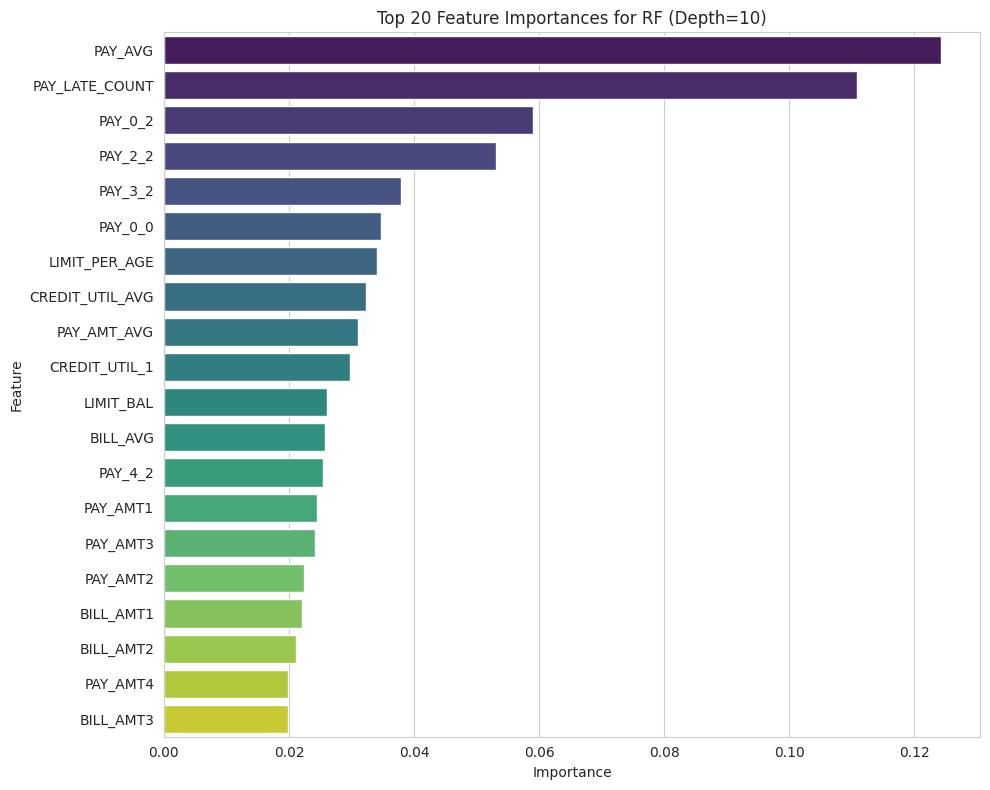

In [49]:
# Best Model - Feature Importance ===
if 'best_model_name' in locals():
    print("\n--- Feature Importance Analysis ---")
    classifier = best_pipeline.named_steps['classifier']
    preprocessor_step = best_pipeline.named_steps['preprocessor']

    all_feature_names = None
    try:
        # Get feature names from ColumnTransformer
        cat_features_out = preprocessor_step.named_transformers_['cat'].get_feature_names_out(categorical_features)
        num_features_out = preprocessor_step.named_transformers_['num'].get_feature_names_out(numeric_features)

        # Combine all feature names in the correct order
        all_feature_names = np.concatenate([num_features_out, cat_features_out])

        # Handle 'remainder=passthrough' if any
        if preprocessor_step.remainder == 'passthrough':
            original_cols = X_train.columns.tolist()
            transformed_cols = numeric_features + categorical_features
            remainder_cols = [col for col in original_cols if col not in transformed_cols]

            if len(remainder_cols) > 0:
                print(f"Found remainder columns: {remainder_cols}")
                all_feature_names = np.concatenate([all_feature_names, remainder_cols])
            else:
                 print("Remainder is passthrough, but no remainder columns were found.")

    except Exception as e:
        print(f"Error getting feature names: {e}. Falling back to basic lists.")
        # This fallback is less accurate due to OHE
        all_feature_names = numeric_features + [f"cat_{i}" for i in range(len(categorical_features) * 10)] # Crude fallback


    feature_imp_df = None
    if all_feature_names is not None:
        if hasattr(classifier, 'feature_importances_'):
            print("Model has 'feature_importances_'")
            importances = classifier.feature_importances_

            if len(all_feature_names) == len(importances):
                feature_imp_df = pd.DataFrame({
                    'Feature': all_feature_names,
                    'Importance': importances
                }).sort_values(by='Importance', ascending=False)

                plt.figure(figsize=(10, 8))
                sns.barplot(data=feature_imp_df.head(20), x='Importance', y='Feature', palette='viridis')
                plt.title(f'Top 20 Feature Importances for {best_model_name}')
            else:
                print(f"Warning: Feature names count ({len(all_feature_names)}) does not match importances count ({len(importances)}). Skipping plot.")

        elif hasattr(classifier, 'coef_'):
            print("Model has 'coef_'")
            # Handle both (n_classes, n_features) and (n_features,)
            if classifier.coef_.ndim > 1:
                coefficients = classifier.coef_[0] # Assume binary or first class
            else:
                coefficients = classifier.coef_

            if len(all_feature_names) == len(coefficients):
                feature_imp_df = pd.DataFrame({
                    'Feature': all_feature_names,
                    'Coefficient': coefficients
                })
                feature_imp_df['Abs_Coefficient'] = feature_imp_df['Coefficient'].abs()
                feature_imp_df = feature_imp_df.sort_values(by='Abs_Coefficient', ascending=False)

                plt.figure(figsize=(10, 8))
                sns.barplot(data=feature_imp_df.head(20), x='Coefficient', y='Feature', palette='vlag')
                plt.title(f'Top 20 Feature Coefficients for {best_model_name}')
            else:
                print(f"Warning: Feature names count ({len(all_feature_names)}) does not match coefficients count ({len(coefficients)}). Skipping plot.")

        else:
            print(f"Cannot extract feature importances for {best_model_name}.")

        if feature_imp_df is not None:
            print(f"\nTop 10 Most Important Features for {best_model_name}:")
            print(feature_imp_df.head(10).to_markdown(index=False, floatfmt=".4f"))
            plt.tight_layout()
            plt.savefig('best_model_feature_importance_v2_FE.png')
            print("Saved 'best_model_feature_importance_v2_FE.png'")
        else:
            print(f"Could not generate feature importance plot for {best_model_name}.")
    else:
        print("Could not determine feature names, skipping feature importance.")

else:
    print("Skipping feature importance (no best model found).")


print("\n\n--- Notebook execution finished. ---")